## 回溯算法核心思想与题型概览

### 一、什么是回溯算法

回溯算法（Backtracking）本质上是一种**系统化的穷举搜索策略**，其核心思想可以用一句话概括：在一棵隐式的决策树上进行深度优先搜索，当发现当前路径无法通向合法解时，主动撤销上一步操作并尝试其他分支。

与朴素的暴力枚举不同，回溯的精髓在于"剪枝"（Pruning）——在搜索过程中提前判断某条路径的不可行性，从而避免无效的状态扩展。这使得回溯算法在面对组合爆炸问题时，仍能以远优于全量枚举的效率找到答案。

理解回溯最直观的方式是将其想象成走迷宫：你沿某条通道前进，若遇到死路，则原路返回到上一个岔口，换一条路继续探索。"前进"对应**做选择并进入下一层递归**，"返回"对应**撤销选择并退出当前递归层**，这一"做选择 → 递归 → 撤销选择"的三步式模板，构成了几乎所有回溯问题的骨架。

### 二、回溯算法的通用框架

回溯的代码结构高度统一，其伪码骨架如下：

```
def backtrack(路径, 选择列表):
    if 满足终止条件:
        记录结果
        return
    
    for 选择 in 选择列表:
        if 不满足约束条件:
            continue  # 剪枝
        做选择（将选择加入路径）
        backtrack(新路径, 新选择列表)
        撤销选择（将选择从路径中移除）
```

这个框架的核心在于**状态的可逆性**：每一步操作在递归返回后必须被完整撤销，以确保下一次选择在一个干净的状态上进行。理解这一点是掌握回溯算法的关键，也是初学者最容易出错的地方——若忘记撤销，状态将被污染，导致后续搜索在错误的基础上进行。

### 三、常见题型分类

回溯算法的应用场景虽然广泛，但从解空间的结构来看，可以归纳为以下几类核心题型。

**第一类：全排列问题（Permutations）。** 这是回溯最经典的入门题型。给定一组元素，要求枚举其所有排列方式。决策树的每一层代表"为当前位置选择哪个元素"，每次选择时需排除已使用的元素（通常用 `visited` 数组标记）。全排列的解空间大小为 $n!$，枝叶数量随元素增加急剧膨胀，因此剪枝策略（如去重处理含重复元素的排列）至关重要。

**第二类：子集与组合问题（Subsets & Combinations）。** 与排列不同，组合问题不关心元素的顺序，只关注"选了哪些"。典型题目包括求所有子集、从 $n$ 个数中选 $k$ 个的所有组合，以及组合总和（元素可重复使用）。这类问题的关键在于通过一个"起始索引"（`start`）来控制搜索方向，确保后续递归只从当前元素之后选取，从而天然地避免重复组合的生成。

**第三类：切割问题（Partitioning）。** 给定一个字符串，要求按某种规则（如每段都是回文串）进行切割，枚举所有合法的切割方案。这类问题将"选择"定义为"在当前位置的下一步切割点在哪里"，本质上与组合问题同构，但结合了字符串判断逻辑，对状态定义的清晰度要求更高。

**第四类：棋盘类问题（Grid/Board Problems）。** N 皇后、数独求解是这一类型的代表。搜索空间是一个二维棋盘，每一步在棋盘某一行（或某一格）做出放置决策，并需要实时验证与已放置元素之间的约束（如列冲突、对角线冲突）。这类问题的剪枝约束最为复杂，也因此能最直观地体现剪枝对搜索效率的决定性影响。

**第五类：路径搜索问题（Path Search）。** 在矩阵或图中搜索满足特定条件的路径，例如单词搜索（Word Search）——在字母矩阵中判断某个单词是否存在连续路径。这类问题需要在状态中记录"已访问节点"，并在回溯时恢复其未访问状态，否则会出现路径交叉的错误。

### 四、小结与学习建议

回溯算法的学习有一条清晰的路径：先用全排列彻底理解"做选择 → 递归 → 撤销选择"的三步式框架与决策树的可视化思维；再通过子集/组合类题型掌握"起始索引"控制重复的技巧；最后通过 N 皇后等约束复杂的题目锤炼剪枝能力。

需要特别警惕的两个常见误区是：其一，**忘记撤销操作**，导致状态污染；其二，**去重逻辑错误**，在含重复元素的题目中（如排列 II、组合总和 II），正确的去重通常需要先排序，再配合"同层跳过相同元素"的策略，而非仅依赖 `visited` 数组。

建议在学习过程中，对每道题都手动画出决策树，明确每一层的"选择列表"和"终止条件"，这将极大加速对问题结构的理解与建模能力的培养。

## 46. 全排列

给定一个不含重复数字的数组 nums ，返回其 所有可能的全排列 。你可以 按任意顺序 返回答案。

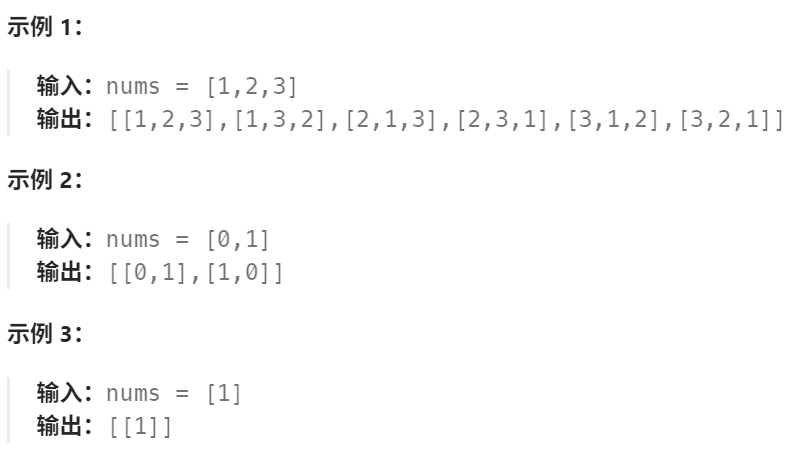

In [15]:
from typing import List

class Solution:
    def permute(self, nums: List[int]) -> List[List[int]]:
        result = []           # 存储所有合法排列
        path = []             # 当前递归路径（即当前正在构造的排列）
        used = [False] * len(nums)  # 标记每个元素是否已被当前路径使用

        def backtrack():
            # ── 终止条件：路径长度等于数组长度，说明已构成一个完整排列 ──
            if len(path) == len(nums):
                result.append(path[:])  # 必须做深拷贝，否则后续撤销会修改已记录的结果
                return

            # ── 遍历所有候选元素 ──
            for i in range(len(nums)):
                # 剪枝：跳过已在当前路径中使用的元素
                if used[i]:
                    continue

                # ── 做选择 ──
                used[i] = True
                path.append(nums[i])

                # 递归进入下一层, 同时要撤销选择（回溯的核心：恢复现场）
                backtrack()
                path.pop()
                used[i] = False

        backtrack()
        return result
nums = [1, 2, 3]
print(Solution().permute(nums))

[[1, 2, 3], [1, 3, 2], [2, 1, 3], [2, 3, 1], [3, 1, 2], [3, 2, 1]]


**解题思路**

全排列问题的决策树结构非常清晰：树的每一层代表"为当前位置选择一个元素"，每个节点的分支数等于剩余未使用的元素数量。当路径长度等于数组长度时，即到达叶节点，记录一个完整排列。

**时间复杂度：$O(n \times n!)$**

全排列共有 $n!$ 个叶节点，每次到达叶节点时需执行 `path[:]` 深拷贝操作，耗时 $O(n)$，因此仅叶节点的拷贝开销即为 $O(n \times n!)$。除此之外，中间节点的总数为 $\sum_{k=0}^{n-1} \frac{n!}{k!}$，该值渐近意义下同样被 $O(n \times n!)$ 所控制，故整体时间复杂度为 $O(n \times n!)$。

**空间复杂度：$O(n)$**

`path` 数组和 `used` 数组各占 $O(n)$ 空间，递归调用栈的最大深度为 $n$，同样占用 $O(n)$ 的栈空间。存储最终结果所需的 $O(n \times n!)$ 空间通常不计入算法本身的空间复杂度（属于输出空间），若计入则为 $O(n \times n!)$。

---


## 78. 子集

给你一个整数数组 nums ，数组中的元素 互不相同 。返回该数组所有可能的子集（幂集）。

解集 不能 包含重复的子集。你可以按 任意顺序 返回解集。

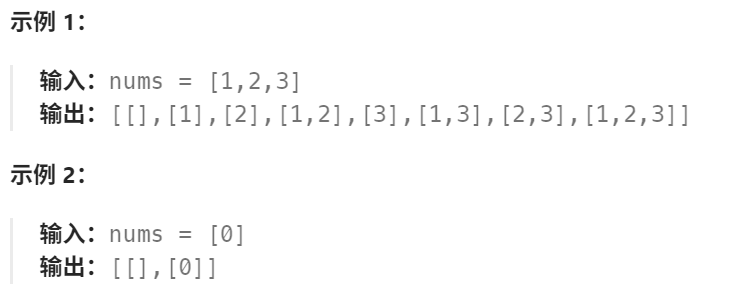

In [16]:
from typing import List

class Solution:
    def subsets(self, nums: List[int]) -> List[List[int]]:
        result = []
        path = []

        def backtrack(start):
            # ── 每进入一个节点，当前 path 即为一个合法子集，直接记录 ──
            # 注意：根节点对应空集 []，同样需要被收录
            result.append(path[:])

            # ── 从 start 开始遍历，避免重复选取已考虑过的元素 ──
            for i in range(start, len(nums)):

                # ── 做选择 ──
                path.append(nums[i])

                # ── 递归：下一层只能从 i+1 开始选，保证元素不重复使用 ──
                backtrack(i + 1)

                # ── 撤销选择 ──
                path.pop()

        backtrack(0)
        return result


# 决策树示意（以 `[1, 2, 3]` 为例）
# 记录时机：每到达一个节点即记录

# []                          ← 记录 []
# ├── [1]                     ← 记录 [1]
# │   ├── [1,2]               ← 记录 [1,2]
# │   │   └── [1,2,3]         ← 记录 [1,2,3]
# │   └── [1,3]               ← 记录 [1,3]
# ├── [2]                     ← 记录 [2]
# │   └── [2,3]               ← 记录 [2,3]
# └── [3]                     ← 记录 [3]

**解题思路**

子集问题与全排列的关键区别在于：排列问题只在叶节点记录结果，而子集问题需要在决策树的每一个节点（包括根节点）都记录结果，因为每个中间状态本身就是一个合法子集。
控制重复的核心手段是引入 start 参数——每一层递归只从 start 索引之后的元素中选取，天然保证了每个组合不会因顺序不同而重复出现。

**时间复杂度：$O(n \times 2^n)$**

共有 $2^n$ 个子集，每次到达节点时执行 `path[:]` 拷贝操作。拷贝的代价取决于当前路径长度，对所有节点求和即为所有子集的长度之和。长度为 $k$ 的子集共有 $\binom{n}{k}$ 个，因此总拷贝代价为：

$$\sum_{k=0}^{n} k \cdot \binom{n}{k} = n \cdot 2^{n-1}$$

渐近意义下为 $O(n \times 2^n)$，这也是整体时间复杂度的瓶颈所在。

**空间复杂度：$O(n)$**

`path` 数组的最大长度为 $n$，递归调用栈的最大深度同样为 $n$，因此算法本身的额外空间开销为 $O(n)$。若将输出结果计入，则为 $O(n \times 2^n)$。


**与全排列的横向对比**

| 维度 | 全排列（LC 46） | 子集（LC 78） |
|------|--------------|-------------|
| 记录时机 | 仅在叶节点（路径长度 = n） | 每个节点均记录 |
| 去重手段 | `used[]` 标记已选元素 | `start` 索引限制选取范围 |
| 解的数量 | $n!$ | $2^n$ |
| 元素顺序 | 有序（[1,2] ≠ [2,1]） | 无序（[1,2] = [2,1]） |

子集问题是组合类回溯的基础模型，`start` 参数的设计思想在组合总和、切割问题等一系列变体中被反复复用，值得重点理解。

---

## 17. 电话号码的字母组合

给定一个仅包含数字 2-9 的字符串，返回所有它能表示的字母组合。答案可以按 任意顺序 返回。

给出数字到字母的映射如下（与电话按键相同）。注意 1 不对应任何字母。

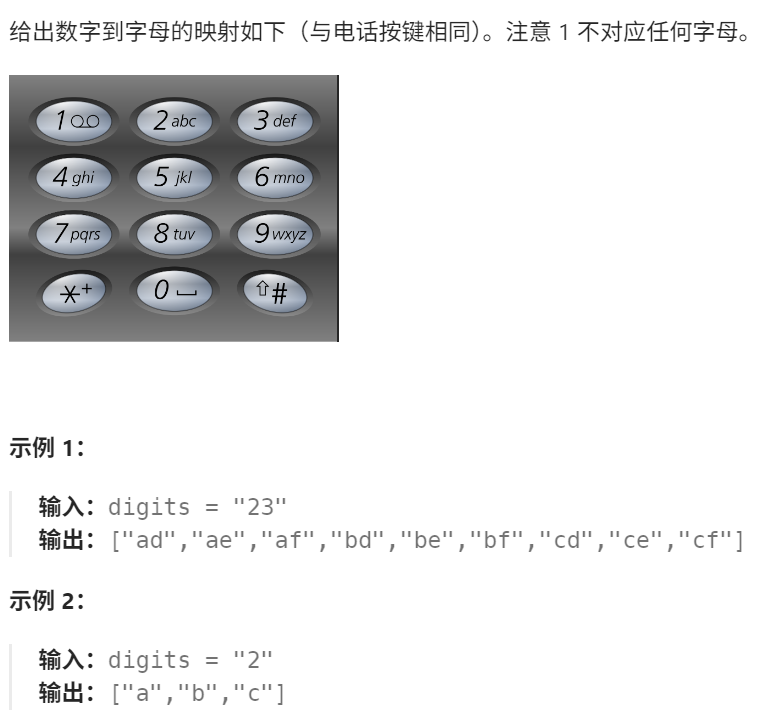

In [17]:
from typing import List

class Solution:
    def letterCombinations(self, digits):
        # 边界处理：输入为空时直接返回空列表
        if not digits:
            return []

        # 数字到字母的映射表
        phone_map = {
            "2": "abc", "3": "def",
            "4": "ghi", "5": "jkl", "6": "mno",
            "7": "pqrs", "8": "tuv", "9": "wxyz"
        }

        result = []
        path = []  # 存储当前路径上已选择的字母

        def backtrack(index):
            # ── 终止条件：路径长度等于 digits 长度，已为每个数字选定一个字母 ──
            if index == len(digits):
                result.append("".join(path))  # 将字符列表拼接为字符串后记录
                return

            # ── 取出当前层对应数字的字母集合 ──
            letters = phone_map[digits[index]]

            for letter in letters:
                # ── 做选择 ──
                path.append(letter)

                # ── 递归：处理下一个数字 ──
                backtrack(index + 1)

                # ── 撤销选择 ──
                path.pop()

        backtrack(0)
        return result
digits = "23"
print(Solution().letterCombinations(digits))


['ad', 'ae', 'af', 'bd', 'be', 'bf', 'cd', 'ce', 'cf']


**解题思路**

本题与子集、全排列的本质区别在于：每一层递归的选择列表不再来自同一个数组，而是由当前处理的数字所对应的字母集合动态决定。决策树的层数等于输入字符串的长度，第 ii
i 层的分支数等于第 ii
i 个数字所映射的字母数量。当路径长度等于输入字符串长度时，即到达叶节点并记录结果。由于每一层的选择来源天然不同，本题无需
start 参数控制重复，也无需 used 数组标记状态，结构是所有回溯题型中最为干净的一类。


**决策树示意（以输入 `"23"` 为例）**

```
[]
├── [a]                 ← digits[0]='2'，从 "abc" 中选
│   ├── [a,d] ✓         ← digits[1]='3'，从 "def" 中选
│   ├── [a,e] ✓
│   └── [a,f] ✓
├── [b]
│   ├── [b,d] ✓
│   ├── [b,e] ✓
│   └── [b,f] ✓
└── [c]
    ├── [c,d] ✓
    ├── [c,e] ✓
    └── [c,f] ✓
```

树的深度固定为 $n$（输入字符串长度），每层的分支数为对应数字的字母数（3 或 4），叶节点数即为最终结果数量。

**复杂度分析**

**时间复杂度：$O(4^n \times n)$**

每个数字最多对应 4 个字母（`7` 和 `9`），因此最坏情况下叶节点数为 $4^n$。每次到达叶节点时执行 `"".join(path)` 操作，耗时 $O(n)$，故整体时间复杂度为 $O(4^n \times n)$。实际场景中多数数字只对应 3 个字母，平均性能优于此上界。

**空间复杂度：$O(n)$**

`path` 数组的最大长度为 $n$，递归调用栈的最大深度同为 $n$，算法本身的额外空间开销为 $O(n)$。输出结果若计入则为 $O(4^n \times n)$。

**三题横向对比**

| 维度 | 全排列（LC 46） | 子集（LC 78） | 电话号码（LC 17） |
|------|--------------|-------------|----------------|
| 记录时机 | 仅叶节点 | 每个节点 | 仅叶节点 |
| 每层选择来源 | 同一数组（排除已用） | 同一数组（限制起始位） | 不同字母集合（按数字映射） |
| 去重手段 | `used[]` 标记 | `start` 索引 | 无需去重 |
| 解的数量 | $n!$ | $2^n$ | $\leq 4^n$ |

本题是回溯框架中"选择列表动态变化"这一模式的标准范例，理解其决策树结构有助于日后处理词语接龙、多级映射等更复杂的变体问题。

---

## 39. 组合总和

给你一个 无重复元素 的整数数组 candidates 和一个目标整数 target ，找出 candidates 中可以使数字和为目标数 target 的 所有 不同组合 ，并以列表形式返回。你可以按 任意顺序 返回这些组合。

candidates 中的 同一个 数字可以 无限制重复被选取 。如果至少一个数字的被选数量不同，则两种组合是不同的。 

对于给定的输入，保证和为 target 的不同组合数少于 150 个。
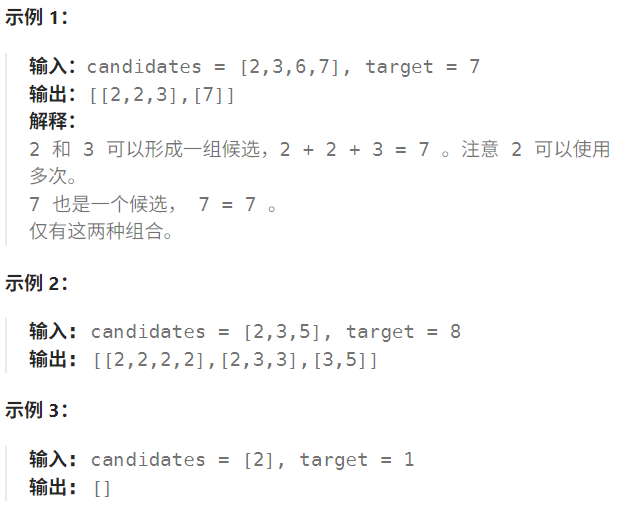

In [18]:
class Solution:
    def combinationSum(self, candidates: List[int], target: int) -> List[List[int]]:
        result = []

        def backtrack(start: int, path: List[int], remaining: int):
            if remaining == 0:          # 恰好凑满，记录结果
                result.append(path[:])
                return
            
            for i in range(start, len(candidates)):
                num = candidates[i]
                if num > remaining:     # 剪枝：当前数已超出剩余目标
                    continue
                path.append(num)
                backtrack(i, path, remaining - num)   # i 而非 i+1，允许重复选
                path.pop()                            # 回溯，撤销选择

        candidates.sort()  # 排序后剪枝更有效
        backtrack(0, [], target)
        return result
        
# 递归树示意（candidates=[2,3,6], target=7）
# backtrack(start=0, path=[], remaining=7)
# ├── 选2 → backtrack(0, [2], 5)
# │     ├── 选2 → backtrack(0, [2,2], 3)
# │     │     ├── 选2 → backtrack(0, [2,2,2], 1)
# │     │     │     └── 选2 → remaining=-1，剪枝
# │     │     │     └── 选3 → remaining=-2，剪枝
# │     │     └── 选3 → backtrack(1, [2,2,3], 0) ✅
# │     └── 选3 → backtrack(1, [2,3], 2) ...
# └── 选3 → backtrack(1, [3], 4)
#       └── 选3 → backtrack(1, [3,3], 1) ...

**核心思想**

本题是经典的**回溯**问题。目标是从候选数组中不断"选或不选"某个数，凑出总和等于 `target` 的所有组合。

关键在于**如何避免重复组合**。例如 `[2,3]` 和 `[3,2]` 本质是同一个组合，需要剪掉。做法是：每次递归时，只允许从当前位置 `start` 往后选，不允许回头选已经考虑过的数，这样天然保证组合有序、不重复。

由于同一个数可以无限重复选取，递归时传入的起始下标仍是当前位置 `start`，而非 `start+1`。

**两个核心细节**

**为什么传 `i` 而不是 `i+1`？**
同一个数可以重复选，传 `i` 允许下一层继续从当前数开始选。若改为 `i+1` 则每个数最多选一次（对应 LeetCode 40 题的逻辑）。

**为什么排序后剪枝更有效？**
排序后，一旦 `candidates[i] > remaining`，后面的数只会更大，整个后续分支可以直接跳过，将 `continue` 改为 `break` 效果更佳：

```python
if num > remaining:
    break  # 排序后后续更大，直接终止循环
```
---

## 22. 括号生成

数字 n 代表生成括号的对数，请你设计一个函数，用于能够生成所有可能的并且 有效的 括号组合。

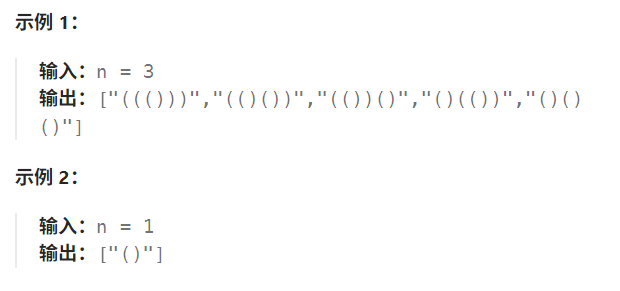

In [19]:
from typing import List

def generateParenthesis(n: int) -> List[str]:
    result = []

    def backtrack(path: str, open: int, close: int):
        # 终止条件：左右括号均用完
        if len(path) == 2 * n:
            result.append(path)
            return
        # 剪枝1：还可以放左括号
        if open < n:
            backtrack(path + "(", open + 1, close)
        # 剪枝2：右括号数量未超过左括号
        if close < open:
            backtrack(path + ")", open, close + 1)

    backtrack("", 0, 0)
    return result


# **执行过程（n=2）**：
# ""
# ├── "("        open=1, close=0
# │   ├── "(("   open=2, close=0
# │   │   └── "(()"  open=2, close=1
# │   │       └── "(())" ✅
# │   └── "()"   open=1, close=1
# │       └── "()("  open=2, close=1
# │           └── "()()" ✅

**结论摘要**

本题本质是**受约束的组合枚举**，最优解法为**回溯（Backtracking）**，通过剪枝将搜索空间从 $2^{2n}$ 压缩到第 $n$ 个卡特兰数 $C_n = \frac{1}{n+1}\binom{2n}{n}$。


**核心约束分析**

合法括号串须满足：

| 约束 | 形式化表述 |
|------|-----------|
| 左括号数量 | `open ≤ n` |
| 右括号数量 | `close ≤ open`（任意前缀中右括号不能多于左括号） |
| 终止条件 | `open == close == n` |


**复杂度对比**

| 方法 | 时间复杂度 | 空间复杂度 | 适用场景 |
|------|-----------|-----------|---------|
| 回溯 | $O(C_n \cdot n)$ | $O(n)$ 递归栈 | **工程首选**，直观高效 |
| DP | $O(C_n \cdot n)$ | $O(C_n \cdot n)$ | 理解递归结构时使用 |

> $C_n \approx \frac{4^n}{n^{3/2}\sqrt{\pi}}$，$n=10$ 时约 16796 个合法组合。

**常见误区**

> ⚠️ **误区 1**：先生成全排列再过滤——时间复杂度退化到 $O(2^{2n})$，完全不必要。
>
> ⚠️ **误区 2**：只判断 `close < n`，忘记 `close < open` 的约束——会生成 `)(` 等非法前缀。


**小结与建议**

- **推荐使用回溯法**：逻辑清晰，剪枝精准，是本类"合法组合枚举"问题的标准范式；
- 该模式可直接推广至**IP地址还原**、**表达式加括号**等变体题；
- 深层本质：回溯树的叶节点数恰好等于卡特兰数，是组合数学与算法设计的经典交叉。

---

## 79. 单词搜索

给定一个 m x n 二维字符网格 board 和一个字符串单词 word 。如果 word 存在于网格中，返回 true ；否则，返回 false 。

单词必须按照字母顺序，通过相邻的单元格内的字母构成，其中“相邻”单元格是那些水平相邻或垂直相邻的单元格。同一个单元格内的字母不允许被重复使用。

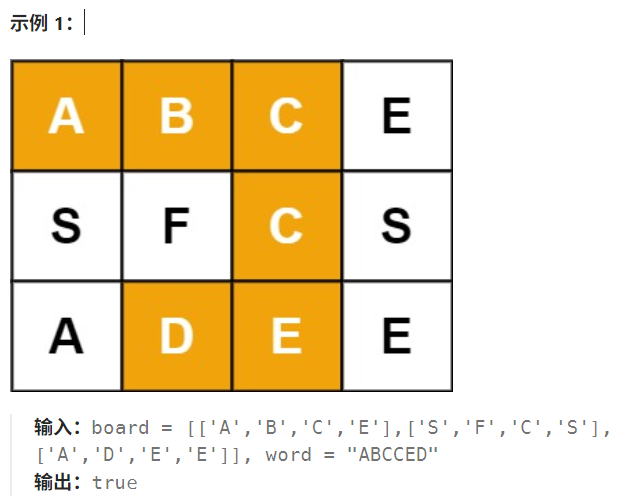

In [20]:
from typing import List

def exist(board: List[List[str]], word: str) -> bool:
    m, n = len(board), len(board[0])
    
    def dfs(i: int, j: int, k: int) -> bool:
        # 终止条件：所有字符匹配完成
        if k == len(word):
            return True
        # 越界 或 字符不匹配 —— 剪枝
        if not (0 <= i < m and 0 <= j < n) or board[i][j] != word[k]:
            return False
        
        # 标记当前格子为"已访问"（原地修改）
        tmp, board[i][j] = board[i][j], '#'
        
        # 向四个方向递归
        found = (dfs(i+1, j, k+1) or
                 dfs(i-1, j, k+1) or
                 dfs(i, j+1, k+1) or
                 dfs(i, j-1, k+1))
        
        # 回溯：还原现场
        board[i][j] = tmp
        return found
    
    # 枚举所有起点
    for i in range(m):
        for j in range(n):
            if dfs(i, j, 0):
                return True
    return False


# 执行过程追踪（word = "SEE"）

# board:
# A B C E
# S F C S
# A D E E

# 起点 (1,0)='S' → 匹配 word[0]
#   → (2,0)='A' ✗
#   → (0,0)='A' ✗
#   → (1,1)='F' ✗
  
# 起点 (1,3)='S' → 匹配 word[0]
#   → (0,3)='E' → 匹配 word[1]
#     → (0,2)='C' ✗
#     → (1,3)='#' ✗（已访问）
#   → (2,3)='E' → 匹配 word[1]
#     → (3,3)='E' → 匹配 word[2] ✅ 返回 True

### 结论摘要

本题是**网格上的 DFS + 回溯**的经典范式。核心思路：以每个格子为起点，递归向四个方向延伸匹配，用"原地标记已访问"实现 O(1) 空间的路径追踪，回溯时还原现场。


### 问题建模

```
board:                word: "ABCCED"
A B C E
S F C S              路径: A→B→C→C→E→D  ✅
A D E E
```

本质是在一棵**隐式四叉树**上做深度优先搜索，每层对应单词的第 `k` 个字符。



### 核心设计决策

| 决策点 | 选择 | 理由 |
|--------|------|------|
| 访问标记 | 原地修改为 `#` | 避免额外 `visited` 数组，O(1) 空间 |
| 剪枝时机 | 进入递归前立即校验 | 减少无效递归调用 |
| 提前终止 | 找到答案立即返回 | 避免继续无意义搜索 |


### 进阶剪枝：字符频次预检

在正式 DFS 前，先统计 `word` 中各字符频次，若 `board` 中某字符数量不足，直接返回 `False`。

```python
from collections import Counter

def exist(board: List[List[str]], word: str) -> bool:
    # 剪枝：字符频次预检
    board_cnt = Counter(c for row in board for c in row)
    word_cnt  = Counter(word)
    if any(word_cnt[c] > board_cnt[c] for c in word_cnt):
        return False
    
    # 方向优化：若 word 尾部比首部更稀有，则反转 word 减少搜索量
    m, n = len(board), len(board[0])
    if board_cnt[word[0]] > board_cnt[word[-1]]:
        word = word[::-1]

    # ... 下同标准 DFS ...
```

> **原理**：反转 `word` 后，从出现次数更少的字符开始匹配，等价于从更稀疏的起点出发，大幅裁剪搜索树宽度。

---

### 复杂度分析

| 维度 | 复杂度 | 说明 |
|------|--------|------|
| 时间 | $O(m \cdot n \cdot 3^L)$ | 每个格子为起点，DFS 最多 $3^L$ 条路径（首步 4 方向，后续最多 3 方向，因来路已标记） |
| 空间 | $O(L)$ | 递归栈深度，$L$ 为单词长度 |

---

### 常见误区

> ⚠️ **误区 1**：忘记回溯，将 `board[i][j] = tmp` 漏写。  
> 后果：第一条搜索路径会"永久污染"棋盘，导致后续路径无法使用这些格子。
>
> ⚠️ **误区 2**：用独立 `visited` 数组，但每次 DFS 启动时忘记重置。  
> 建议直接使用原地修改方案，彻底规避此问题。
>
> ⚠️ **误区 3**：`k == len(word)` 的终止检查放在字符匹配**之后**，导致越界或逻辑错误。  
> 应将其作为**第一个**条件判断。

---

### 小结

- **核心范式**：DFS + 回溯 + 原地标记，是网格路径类问题的标准模板；
- **关键技巧**：原地修改代替 `visited` 数组；终止条件前置；方向剪枝；
- **可推广至**：LeetCode 212（单词搜索 II，需结合 Trie 树批量搜索）、130（被围绕的区域）等变体。

---

## 131. 分割回文串

给你一个字符串 s，请你将 s 分割成一些 子串，使每个子串都是 回文串 。返回 s 所有可能的分割方案。

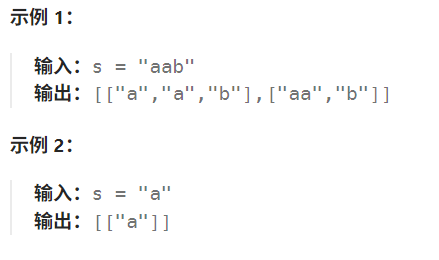

### 结论摘要

本题是**回溯枚举切割点 + 回文预判**的经典组合。朴素回溯每次判断回文需 $O(n)$，最优方案是**预处理 DP 回文表**将每次查询降至 $O(1)$，整体复杂度由 $O(n \cdot 2^n)$ 优化至 $O(n^2 + 2^n)$。

---

### 问题建模

```
s = "aab"

切割决策树（每层选择"下一个回文子串的右边界"）：

""
├── "a" → "a" → "b"       ✅ ["a","a","b"]
├── "aa" → "b"             ✅ ["aa","b"]
└── "aab"                  ✗ 非回文，剪枝
```

本质是：在字符串上枚举所有**前缀切割点**，保证每段均为回文，最终收集所有合法方案。

---

### 方法一：朴素回溯（理解基础）

```python
from typing import List

def partition(s: str) -> List[List[str]]:
    result, path = [], []

    def backtrack(start: int):
        if start == len(s):          # 整串切完，收录方案
            result.append(path[:])
            return
        for end in range(start + 1, len(s) + 1):
            sub = s[start:end]
            if sub == sub[::-1]:     # O(n) 回文判断
                path.append(sub)
                backtrack(end)
                path.pop()           # 回溯

    backtrack(0)
    return result
```

---

### 方法二：DP 预处理 + 回溯（推荐）

**核心思路**：先用区间 DP 预计算所有子串是否为回文，查表 $O(1)$，回溯时零额外开销。

#### Step 1：预处理回文表

定义 `is_palindrome[i][j]` = `s[i..j]` 是否为回文：

$$
\text{is\_palindrome}[i][j] = \begin{cases}
\text{True} & \text{if } i \geq j \\
s[i] = s[j] \;\wedge\; \text{is\_palindrome}[i+1][j-1] & \text{otherwise}
\end{cases}
$$

```
s = "aab"，索引 0 1 2

is_palindrome 表（下三角）：
     0    1    2
0  [ T    F    F ]
1  [ -    T    F ]
2  [ -    -    T ]

is_palindrome[0][1]: s[0]='a'==s[1]='a' ∧ is_palindrome[1][0]=T → True
is_palindrome[0][2]: s[0]='a'!=s[2]='b' → False
```

#### Step 2：回溯 + 查表

```python
def partition(s: str) -> List[List[str]]:
    n = len(s)
    
    # ── Step 1：区间 DP 预处理 ──────────────────────────────
    is_pal = [[False] * n for _ in range(n)]
    for i in range(n - 1, -1, -1):       # 从右向左，保证子问题先算
        for j in range(i, n):
            if s[i] == s[j] and (j - i <= 2 or is_pal[i+1][j-1]):
                is_pal[i][j] = True
    
    # ── Step 2：回溯枚举切割方案 ───────────────────────────
    result, path = [], []

    def backtrack(start: int):
        if start == n:
            result.append(path[:])
            return
        for end in range(start, n):
            if is_pal[start][end]:        # O(1) 查表
                path.append(s[start:end+1])
                backtrack(end + 1)
                path.pop()

    backtrack(0)
    return result
```

---

### 两种方法对比

| 维度 | 朴素回溯 | DP + 回溯 |
|------|---------|----------|
| 回文判断 | $O(n)$ /次 | $O(1)$ /次（查表） |
| 预处理开销 | 无 | $O(n^2)$ 时间 + 空间 |
| 总时间复杂度 | $O(n \cdot 2^n)$ | $O(n^2 + 2^n)$ |
| **适用场景** | $n \leq 10$ | **$n$ 较大时首选** |

---

### 回溯树可视化（s = "aab"）

```
backtrack(0)
├── is_pal[0][0]="a" ✅
│   backtrack(1)
│   ├── is_pal[1][1]="a" ✅
│   │   backtrack(2)
│   │   └── is_pal[2][2]="b" ✅
│   │       backtrack(3) → 收录 ["a","a","b"] ✅
│   └── is_pal[1][2]="ab" ✗ 跳过
├── is_pal[0][1]="aa" ✅
│   backtrack(2)
│   └── is_pal[2][2]="b" ✅
│       backtrack(3) → 收录 ["aa","b"] ✅
└── is_pal[0][2]="aab" ✗ 跳过
```

---

### 复杂度分析

| 维度 | 复杂度 | 说明 |
|------|--------|------|
| 时间 | $O(n^2 + 2^n)$ | $n^2$ 预处理 + $2^n$ 枚举所有切割方案 |
| 空间 | $O(n^2)$ | 回文表存储；递归栈 $O(n)$ |

> **为什么是 $2^n$**：长度为 $n$ 的串有 $n-1$ 个切割位置，每处可切或不切，最多 $2^{n-1}$ 种方案。

---

### 常见误区

> ⚠️ **误区 1**：DP 遍历顺序错误，`i` 应从大到小（或确保 `is_pal[i+1][j-1]` 先被计算），否则状态依赖未满足。
>
> ⚠️ **误区 2**：回溯时 `end` 的索引混淆——切片用 `s[start:end+1]`（闭区间），递归传入 `end+1`（开区间起点）。
>
> ⚠️ **误区 3**：收录方案时写 `result.append(path)` 而非 `result.append(path[:])`，导致所有结果指向同一个列表引用。

---

### 小结

- **推荐方案**：DP 预处理回文表 + 回溯枚举，兼顾实现清晰与运行效率；
- **核心思想**：将"重复计算"（每次 $O(n)$ 判断回文）通过预处理转化为"一次性开销"，是算法优化的通用策略；
- **可推广至**：LeetCode 132（分割回文串 II，最少切割次数，纯 DP 问题）、1278（分割回文串 III）等变体。

---

## 51. N 皇后

按照国际象棋的规则，皇后可以攻击与之处在同一行或同一列或同一斜线上的棋子。

n 皇后问题 研究的是如何将 n 个皇后放置在 n×n 的棋盘上，并且使皇后彼此之间不能相互攻击。

给你一个整数 n ，返回所有不同的 n 皇后问题 的解决方案。

每一种解法包含一个不同的 n 皇后问题 的棋子放置方案，该方案中 'Q' 和 '.' 分别代表了皇后和空位。

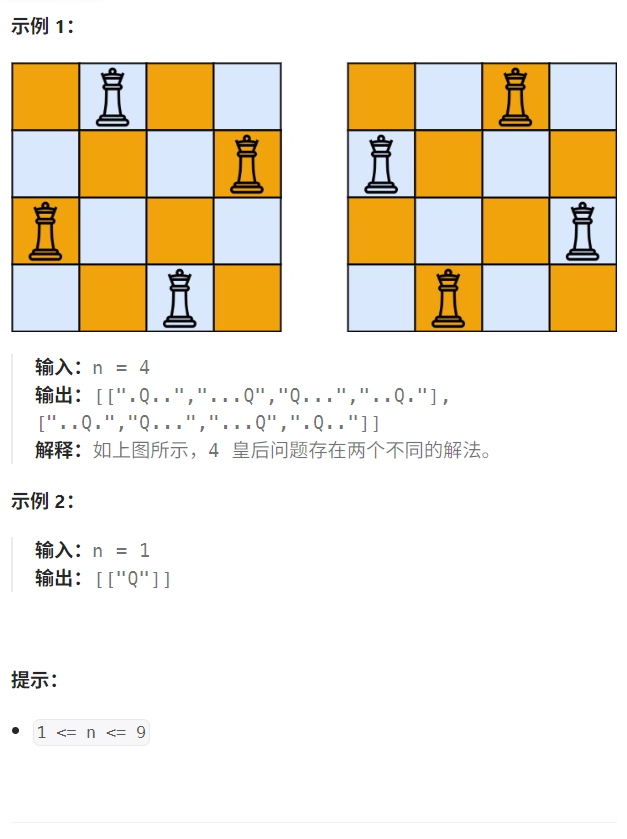

### 结论摘要

N 皇后是**回溯 + 约束传播**的终极范式题。关键洞察：**逐行放置**天然保证行不冲突，只需用三个集合 $O(1)$ 检测列与两条对角线冲突。进一步可用**位运算**压缩状态，将常数优化到极致。

---

### 约束几何分析

```
棋盘坐标 (row, col)，三类攻击方向：

列：        col 相同
主对角线：  row - col 相同（左上→右下）
副对角线：  row + col 相同（右上→左下）

n=4 示例：
. Q . .    col=1, 主对角 0-1=-1, 副对角 0+1=1
. . . Q    col=3, 主对角 1-3=-2, 副对角 1+3=4
Q . . .    col=0, 主对角 2-0= 2, 副对角 2+0=2
. . Q .    col=2, 主对角 3-2= 1, 副对角 3+2=5
```

三个集合各自记录"已被占用"的 `col`、`row-col`、`row+col`，新放置前查表即可 $O(1)$ 判断合法性。

---

### 标准实现（集合标记法）

```python
from typing import List

def solveNQueens(n: int) -> List[List[str]]:
    result = []
    queens = []          # queens[row] = col，记录每行皇后所在列
    
    cols    = set()      # 已占用的列
    diag1   = set()      # 已占用的主对角线（row - col）
    diag2   = set()      # 已占用的副对角线（row + col）

    def backtrack(row: int):
        if row == n:
            # 构造棋盘输出
            board = []
            for c in queens:
                board.append('.' * c + 'Q' + '.' * (n - c - 1))
            result.append(board)
            return

        for col in range(n):
            if col in cols or (row - col) in diag1 or (row + col) in diag2:
                continue                      # 冲突，剪枝
            
            # 放置皇后
            queens.append(col)
            cols.add(col)
            diag1.add(row - col)
            diag2.add(row + col)

            backtrack(row + 1)

            # 回溯，撤销放置
            queens.pop()
            cols.remove(col)
            diag1.remove(row - col)
            diag2.remove(row + col)

    backtrack(0)
    return result
```

---

### 方法二：位运算优化（进阶）

**核心思想**：用整数的二进制位代替集合，位操作比哈希集合快一个量级。

```
n=4，用低 4 位表示 4 列：
cols  = 0b0010  → 第1列被占
diag1 = 0b0100  → 主对角冲突位（每行右移一位传播）
diag2 = 0b0001  → 副对角冲突位（每行左移一位传播）

available = (~(cols | diag1 | diag2)) & ((1 << n) - 1)
              ↑ 取反得到可用位              ↑ 掩码截断高位

逐一取最低可用位：
pos = available & (-available)   # 最低置位位（lowbit 技巧）
available &= available - 1       # 清除已选位
```

```python
def solveNQueens(n: int) -> List[List[str]]:
    result  = []
    queens  = []
    mask    = (1 << n) - 1       # 低 n 位全为 1

    def backtrack(row: int, cols: int, diag1: int, diag2: int):
        if row == n:
            board = ['.' * c + 'Q' + '.' * (n - c - 1) for c in queens]
            result.append(board)
            return

        available = (~(cols | diag1 | diag2)) & mask
        while available:
            pos = available & (-available)     # 取最低可用位
            col = pos.bit_length() - 1         # 转换为列号
            queens.append(col)
            backtrack(
                row + 1,
                cols  | pos,
                (diag1 | pos) >> 1,            # 主对角线向下传播（右移）
                (diag2 | pos) << 1 & mask      # 副对角线向下传播（左移）
            )
            queens.pop()
            available &= available - 1         # 清除当前位，枚举下一个

    backtrack(0, 0, 0, 0)
    return result
```

---

### 回溯树剪枝效果（n=4）

```
逐行搜索，每行 4 个位置，共 4^4=256 暴力组合
经约束剪枝后实际节点数：

row=0: 尝试 col ∈ {0,1,2,3}
  col=0:
    row=1: col=1 ✗(副对角), col=2 ✅, col=3 ✅
      col=2:
        row=2: 全部冲突 ✗ ← 整棵子树剪掉
      col=3:
        row=2: col=1 ✅
          row=3: col=... → 找到解 ✅
  col=1:
    row=1: col=3 ✅ → ... → 找到解 ✅
  ... （对称情况）

最终仅 2 个合法解，实际访问节点数远小于 256
```

---

### 两种方法对比

| 维度 | 集合标记法 | 位运算法 |
|------|-----------|---------|
| 冲突检测 | $O(1)$ 哈希查询 | $O(1)$ 位操作（常数更小） |
| 实现复杂度 | 低，直观易懂 | 较高，需熟悉位技巧 |
| 空间 | $O(n)$ 三个集合 | $O(1)$ 三个整数 |
| **推荐场景** | 面试首选 | 性能敏感 / 竞赛 |

---

### 复杂度分析

| 维度 | 复杂度 | 说明 |
|------|--------|------|
| 时间 | $O(n!)$ 上界，实际远小于此 | 第 $k$ 行最多 $n-k$ 个合法位置 |
| 空间 | $O(n^2)$ | 棋盘存储；递归栈 $O(n)$ |

> **解的数量**：$n=8$ 时有 92 个解，$n=12$ 时有 14200 个解，增长极快，这也是为何优化剪枝意义重大。

---

### 常见误区

> ⚠️ **误区 1**：同时检查行冲突——逐行放置已保证每行恰好一个皇后，无需检查行冲突，检查列和两条对角线即可。
>
> ⚠️ **误区 2**：对角线标识计算错误——主对角线用 `row - col`（可为负数，集合可存），副对角线用 `row + col`，两者不可混淆。
>
> ⚠️ **误区 3**：位运算中对角线传播方向搞反——主对角线每向下一行，冲突列号 **+1**，对应整数**右移**；副对角线冲突列号 **-1**，对应**左移**（取决于位序定义，需与列号提取方式一致）。

---

### 小结

- **推荐实现**：集合标记法，逻辑清晰，面试场景表达力强；
- **核心模式**：逐行放置 → 三方向约束 $O(1)$ 检测 → 回溯撤销，是所有排列约束类问题的通用框架；
- **深层本质**：N 皇后等价于在 $n \times n$ 二部图中寻找满足额外对角约束的完美匹配，位运算版本本质上是对约束集合做高效的集合运算；
- **可推广至**：数独求解（LeetCode 37）、图着色问题等更复杂的约束满足问题（CSP）。